In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import yaml
from pathlib import Path

print(f"OpenCV: {cv2.__version__}")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {torch.__version__}")
print("all fine")

OpenCV: 4.13.0
NumPy: 2.4.3
PyTorch: 2.11.0+cpu
all fine


In [ ]:

with open("../configs/config.yaml", "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

print("Config loaded:")
print(f"  Project: {config['project']['name']} v{config['project']['version']}")
print(f"  Image size: {config['image']['input_size']}")
print(f"  Metrics: {config['evaluation']['metrics']}")

Config loaded:
  Project: colorization-mlops v0.1.0
  Image size: [256, 256]
  Metrics: ['psnr', 'ssim', 'lpips']


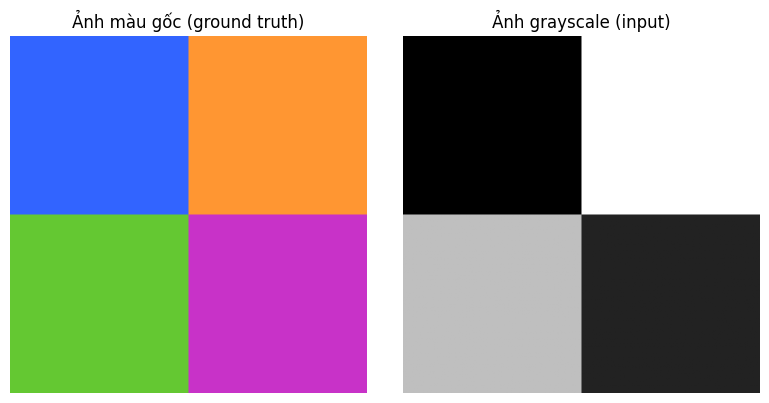

Color shape: (256, 256, 3)
Gray shape:  (256, 256)
Pixel range: [103, 170]


In [ ]:
# Tạo ảnh màu giả để test (sau này thay bằng ảnh thật)
sample_color = np.zeros((256, 256, 3), dtype=np.uint8)
sample_color[:128, :128] = [255, 100, 50]   
sample_color[:128, 128:] = [50, 150, 255]  
sample_color[128:, :128] = [50, 200, 100]  
sample_color[128:, 128:] = [200, 50, 200]  

# Chuyển sang grayscale, INPUT của colorization
gray = cv2.cvtColor(sample_color, cv2.COLOR_BGR2GRAY)


fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(cv2.cvtColor(sample_color, cv2.COLOR_BGR2RGB))
axes[0].set_title("Ảnh màu gốc (ground truth)")
axes[0].axis("off")

axes[1].imshow(gray, cmap="gray")
axes[1].set_title("Ảnh grayscale (input)")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("../results/figures/sample_test.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Color shape: {sample_color.shape}")   # (256, 256, 3)
print(f"Gray shape:  {gray.shape}")           # (256, 256)
print(f"Pixel range: [{gray.min()}, {gray.max()}]")